In [ ]:
!pip install pandas numpy scikit-learn xgboost sentence-transformers matplotlib seaborn nltk wordcloud

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

from sentence_transformers import SentenceTransformer

import nltk
from nltk.corpus import stopwords
import re
import string

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yasserh/twitter-tweets-sentiment-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'twitter-tweets-sentiment-dataset' dataset.
Path to dataset files: /kaggle/input/twitter-tweets-sentiment-dataset


In [ ]:
df = pd.read_csv(f"{path}/Tweets.csv")
df.head()
df.shape
df.info()
df.isnull().sum
df.dropna(inplace=True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   textID         27481 non-null  object
 1   text           27480 non-null  object
 2   selected_text  27480 non-null  object
 3   sentiment      27481 non-null  object
dtypes: object(4)
memory usage: 858.9+ KB


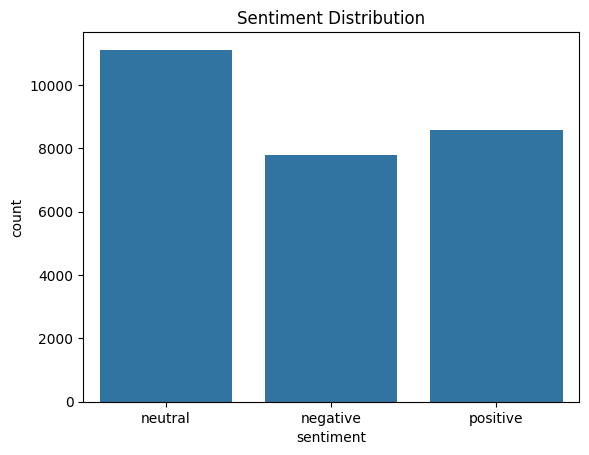

In [ ]:
sns.countplot(x='sentiment', data=df)
plt.title("Sentiment Distribution")
plt.show()


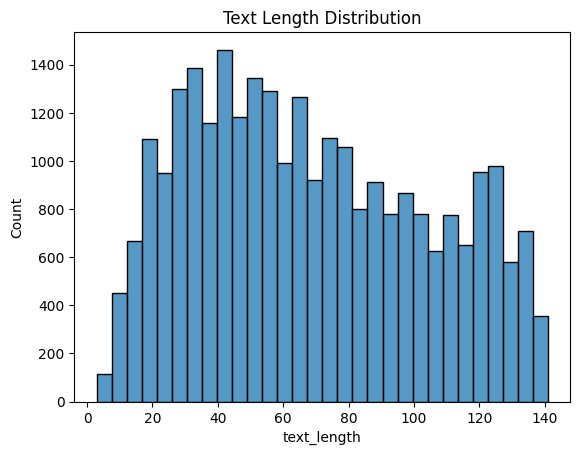

In [ ]:
df['text_length'] = df['text'].astype(str).apply(len)
sns.histplot(df['text_length'], bins=30)
plt.title("Text Length Distribution")
plt.show()

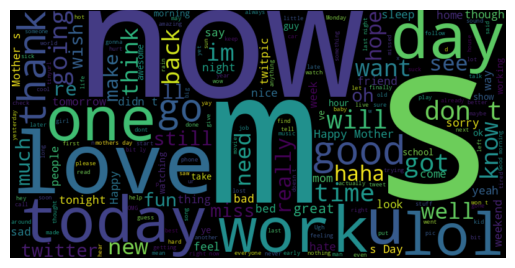

In [ ]:
from wordcloud import WordCloud

text = " ".join(df['text'].astype(str))

wordcloud = WordCloud(width=800, height=400).generate(text)

plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [ ]:
print(df.columns)

Index(['textID', 'text', 'selected_text', 'sentiment', 'text_length'], dtype='object')


In [ ]:
stop_words = set(stopwords.words('english'))

In [ ]:
def clean_text(text):
  text = text.lower()
  text = re.sub(r'http\S+|www\S+|@w+','',text)
  text = text.translate(str.maketrans('','',string.punctuation))
  tokens = [word for word in text.split() if word not in stop_words]
  return " ".join(tokens)

df['clean_text'] = df['text'].astype(str).apply(clean_text)

In [ ]:
model = SentenceTransformer('all-MiniLm-L6-v2')
df['embedding'] = df['clean_text'].apply(lambda x: model.encode(x))
x = np.vstack(df['embedding'].values)
y = df['sentiment']

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
x_train ,x_test ,y_train, y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)

In [ ]:
lr_model = LogisticRegression(max_iter = 1000)
lr_model.fit(x_train, y_train)
lr_pred = lr_model.predict(x_test)

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
le = LabelEncoder()

# Fit and transform y_train and transform y_test
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

xgb_model = XGBClassifier()
xgb_model.fit(x_train, y_train_encoded)
xgb_pred = xgb_model.predict(x_test)

Accuracy Score: 0.6920138257231218
Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.65      0.67      1562
           1       0.65      0.70      0.68      2230
           2       0.75      0.71      0.73      1705

    accuracy                           0.69      5497
   macro avg       0.70      0.69      0.69      5497
weighted avg       0.69      0.69      0.69      5497



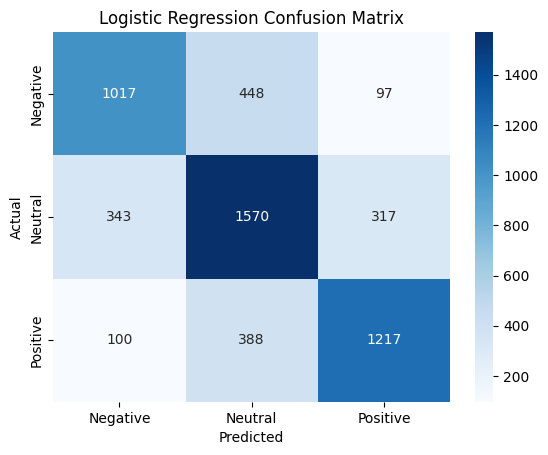

In [ ]:
cm = confusion_matrix(y_test_encoded, le.transform(lr_pred))
print(f"Accuracy Score: {accuracy_score(y_test_encoded, le.transform(lr_pred))}")
print("Classification Report:")
print(classification_report(y_test_encoded, le.transform(lr_pred)))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative','Neutral','Positive'],
            yticklabels=['Negative','Neutral','Positive'])
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
def predict_sentiment(tweet):
    clean = clean_text(tweet)
    embedding = model.encode(clean)
    prediction = xgb_model.predict([embedding])
    return prediction[0]

In [ ]:
tweets = [
    "I love this product so much!",
    "This is the worst service ever.",
    "It was okay, nothing special.",
    "Absolutely fantastic experience!",
    "I am disappointed with the quality."
]

for t in tweets:
    print(f"Tweet: {t}")
    print("Predicted Sentiment:", predict_sentiment(t))
    print()


Tweet: I love this product so much!
Predicted Sentiment: 2

Tweet: This is the worst service ever.
Predicted Sentiment: 0

Tweet: It was okay, nothing special.
Predicted Sentiment: 2

Tweet: Absolutely fantastic experience!
Predicted Sentiment: 2

Tweet: I am disappointed with the quality.
Predicted Sentiment: 0

